In [6]:
import jax.numpy as jnp
import numpy as onp
import matplotlib.pyplot as plt
import matplotlib
from scipy.stats import multivariate_normal as mvn
from sklearn.linear_model import LinearRegression


font = {"size": 20}
matplotlib.rc("font", **font)
matplotlib.rcParams["text.usetex"] = True

import sys

sys.path.append("../models")
from linear_sscr import LinearCR

In [25]:
n = 100
m = 150
p = 2
d = 1

cov = [[2.7, 2.6], [2.6, 2.7]]

# Generate data
n, m = 200, 200
Y = mvn.rvs([0, 0], cov, size=m)
Xa = mvn.rvs([-1, 1], cov, size=n // 2)
Xb = mvn.rvs([1, -1], cov, size=n // 2)
X = onp.concatenate([Xa, Xb], axis=0)

R = (-X[:, 0] + X[:, 1]).reshape(-1, 1)

model = LinearSSCR()
model.fit(X, Y, R, d, print_every=1_000)

preds = model.predict(X)

Step: 0               Log marginal lik.: -1605.99
Step: 1000            Log marginal lik.: -406.67
Step: 2000            Log marginal lik.: -393.06
Step: 3000            Log marginal lik.: -391.22
Estimated W =  [[-1.1862592   0.82070327]]
Estimated S =  [[1.6329613 1.6536142]]
Estimated beta =  [[2.006962]]
Estimated sigma =  [0.05291334]
Estimated tau =  [0.00080821]
Estimated microergodic =  [[-0.98081964  0.9652735 ]]
True microergodic =  [[0.5 0.5]]


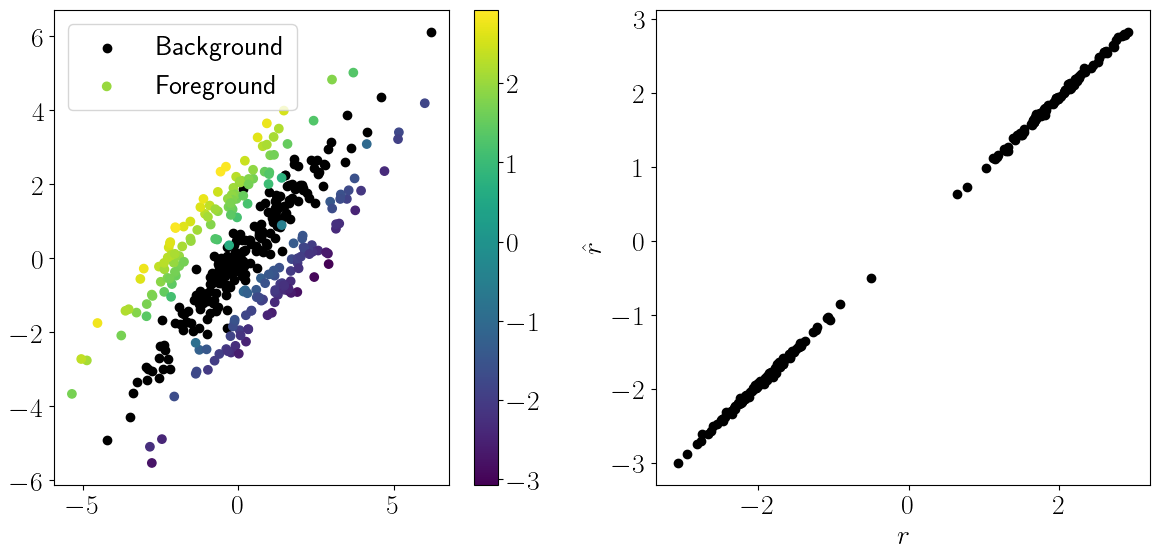

In [26]:

plt.figure(figsize=(12, 6))
plt.subplot(121)
plt.scatter(Y[:, 0], Y[:, 1], c="black", label="Background")
plt.scatter(X[:, 0], X[:, 1], c=R, label="Foreground")
plt.colorbar()
plt.legend()

plt.subplot(122)
plt.scatter(R, preds, c="black")
plt.xlabel(r"$r$")
plt.ylabel(r"$\hat{r}$")
plt.tight_layout()
plt.savefig("./out/simulation_demo.png")
plt.show()

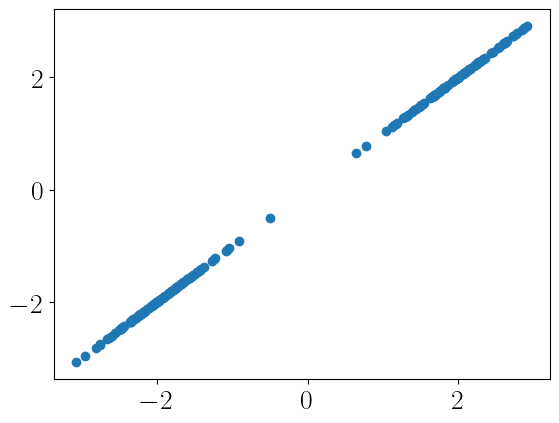

In [27]:
linreg = LinearRegression()
linreg.fit(X, R)
preds_linreg = linreg.predict(X)
plt.scatter(R, preds_linreg)
plt.show()

In [28]:
print(linreg.coef_)

[[-1.  1.]]
